# Miniproyecto 2: Modelo de Heisenberg Clásico (Paramagnetismo)

**Referencia:**
> *Física Estadística: Teoría, Algoritmos y Problemas*
> Johans Restrepo Cárdenas
> Profesor del Instituto de Física, Universidad de Antioquia.

---

## 1. Introducción y Marco Teórico

El **Modelo de Heisenberg Clásico** es fundamental para entender el magnetismo en sistemas donde los efectos cuánticos discretos del espín pueden aproximarse por vectores continuos. A diferencia del modelo de Ising (donde el espín es escalar $S_i = \pm 1$), en el modelo de Heisenberg clásico, el momento magnético $\vec{\mu}$ es un vector tridimensional que puede apuntar en cualquier dirección del espacio.

### Definición del Sistema
Consideramos un sistema de $N$ dipolos magnéticos clásicos no interactuantes (paramagnetismo ideal) en 3D, bajo la influencia de un campo magnético externo uniforme $\vec{H}$ alineado con el eje $z$.

### Hamiltoniano
La energía de interacción de un solo dipolo con el campo externo está dada por el término Zeeman:

$$
E = -\vec{\mu} \cdot \vec{H} = -\mu H \cos(\theta)
$$

Donde:
*   $\mu = |\vec{\mu}|$ es la magnitud del momento magnético.
*   $H = |\vec{H}|$ es la magnitud del campo magnético.
*   $\theta$ es el ángulo entre el vector momento magnético y el campo externo (eje $z$).

### Límite Clásico de Langevin
En el tratamiento cuántico, el operador de espín $\hat{S}$ tiene eigenvalores discretos. Sin embargo, para espines grandes ($S \to \infty$) o altas temperaturas, el espectro discreto se vuelve casi continuo. En este límite clásico, el vector de espín puede orientarse libremente en la esfera unitaria, y la sumatoria sobre estados cuánticos se reemplaza por una integral sobre el ángulo sólido $d\Omega = \sin\theta d\theta d\phi$.

## 2. Desarrollo Analítico Completo

### Función de Partición Monoparticular ($Z_a$)
Para calcular las propiedades termodinámicas, primero evaluamos la función de partición canónica para una sola partícula. La integral se realiza sobre todos los ángulos posibles en coordenadas esféricas:

$$
Z_a = \int_{0}^{2\pi} d\phi \int_{0}^{\pi} d\theta \sin(\theta) e^{-\beta E} = \int_{0}^{2\pi} d\phi \int_{0}^{\pi} d\theta \sin(\theta) e^{\beta \mu H \cos(\theta)}
$$

Donde $\beta = 1/(k_B T)$.

Resolviendo la integral:
1.  La integral sobre $\phi$ es trivial y da $2\pi$.
2.  Para la integral sobre $\theta$, hacemos el cambio de variable $u = \cos(\theta)$, $du = -\sin(\theta) d\theta$.

$$
Z_a = 2\pi \int_{-1}^{1} e^{\eta u} du = 2\pi \left[ \frac{e^{\eta u}}{\eta} \right]_{-1}^{1} = \frac{2\pi}{\eta} (e^{\eta} - e^{-\eta})
$$

$$
Z_a = \frac{4\pi \sinh(\eta)}{\eta}
$$

Definimos el parámetro adimensional $\eta$ como la razón entre la energía magnética y la térmica:
$$\eta = \beta \mu H = \frac{\mu H}{k_B T}$$

### Magnetización Promedio ($\langle \mu_z \rangle$)
La magnetización promedio por partícula es el valor esperado de la componente $z$ del momento magnético. Termodinámicamente, se obtiene derivando el logaritmo de la función de partición:

$$
\langle \mu_z \rangle = \frac{1}{\beta} \frac{\partial \ln Z_a}{\partial H} = \mu \frac{\partial \ln Z_a}{\partial \eta}
$$

Sustituyendo $Z_a$:
$$
\ln Z_a = \ln(4\pi) + \ln(\sinh(\eta)) - \ln(\eta)
$$

$$
\frac{\partial \ln Z_a}{\partial \eta} = \frac{\cosh(\eta)}{\sinh(\eta)} - \frac{1}{\eta} = \coth(\eta) - \frac{1}{\eta}
$$

Por lo tanto, la magnetización total $M = N \langle \mu_z \rangle$ es:
$$
M = N \mu L(\eta)
$$

Donde $L(\eta)$ es la **Función de Langevin**:
$$
L(\eta) = \coth(\eta) - \frac{1}{\eta}
$$

### Energía Promedio y Capacidad Calorífica
La energía interna promedio es:
$$
\langle E \rangle = -N \mu H \langle \cos \theta \rangle = -N \mu H L(\eta)
$$

La capacidad calorífica a volumen constante $C_v$ es:
$$
C_v = \frac{\partial \langle E \rangle}{\partial T} = \frac{\partial \langle E \rangle}{\partial \eta} \frac{\partial \eta}{\partial T}
$$

Dado que $\eta \propto 1/T$, tenemos $\frac{\partial \eta}{\partial T} = -\frac{\eta}{T}$.

$$
C_v = N k_B \left( 1 - \frac{\eta^2}{\sinh^2(\eta)} \right)
$$

## 3. Implementación Computacional (Python)

Utilizaremos el **Algoritmo de Metrópolis basado en Cadenas de Markov (MCMC - Markov Chain Monte Carlo)** para simular el sistema. 

### Fundamento del Método MCMC
El algoritmo de Metrópolis genera una **cadena de Markov** en el espacio de configuraciones del sistema. Una cadena de Markov es una secuencia de estados donde la probabilidad de transición al siguiente estado depende únicamente del estado actual (propiedad de Markov). Las características clave son:

- **Ergodicidad**: La cadena puede alcanzar cualquier configuración desde cualquier estado inicial.
- **Balance Detallado**: Se satisface $P(A \to B) \cdot \pi(A) = P(B \to A) \cdot \pi(B)$, garantizando que la distribución estacionaria sea la de Boltzmann $\pi \propto e^{-\beta E}$.
- **Convergencia**: Tras suficientes pasos, la cadena muestrea configuraciones según la distribución de equilibrio termodinámico.

### Detalles de la implementación
1.  **Librerías**: Usamos `numpy` para cálculos vectoriales y `numba` con `prange` para paralelización en múltiples núcleos.
2.  **Generación de Vectores**: Para evitar sesgos en la esfera, generamos vectores unitarios aleatorios uniformes sobre la superficie esférica.
3.  **Réplicas Estadísticas**: Ejecutamos **10 simulaciones independientes** para cada valor de $\eta$, calculando el valor medio y la desviación estándar como barras de error.
4.  **Algoritmo de Metrópolis**:
    *   Proponemos una nueva orientación aleatoria para un espín.
    *   Calculamos el cambio de energía $\Delta E$.
    *   Aceptamos el cambio con probabilidad $P = \min(1, e^{-\beta \Delta E})$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from tqdm.auto import tqdm
import os

# Usar todos los núcleos disponibles
NUM_CORES = os.cpu_count()
print(f"Núcleos disponibles para paralelización: {NUM_CORES}")

# Configuración de estilo de gráficos
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    if 'seaborn-v0_8-whitegrid' in plt.style.available:
         plt.style.use('seaborn-v0_8-whitegrid')
    else:
         plt.style.use('ggplot')

plt.rcParams.update({'font.size': 12})

Núcleos disponibles para paralelización: 8


In [2]:
@njit
def random_unit_vector():
    """
    Genera un vector unitario aleatorio uniforme en la esfera 3D.
    Utiliza coordenadas esféricas con cos(theta) uniforme para evitar sesgos polares.
    """
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
    
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = costheta
    return np.array([x, y, z])

@njit
def metropolis_step(spins, eta):
    """
    Realiza un paso de Monte Carlo (sweep) sobre todos los espines.
    Este es el núcleo del algoritmo MCMC de Metrópolis.
    
    La cadena de Markov transiciona entre configuraciones según:
    P(aceptar) = min(1, exp(-beta * Delta_E))
    
    spins: array de forma (N, 3)
    eta: parámetro adimensional beta * mu * H
    """
    N = len(spins)
    accepted = 0
    
    for i in range(N):
        # Estado actual en la cadena de Markov
        current_spin = spins[i]
        E_current = -eta * current_spin[2]
        
        # Propuesta de transición (nuevo estado candidato)
        proposed_spin = random_unit_vector()
        E_new = -eta * proposed_spin[2]
        
        # Cambio de energía
        delta_E = E_new - E_current
        
        # Criterio de Metrópolis (regla de aceptación de la cadena de Markov)
        if delta_E <= 0:
            spins[i] = proposed_spin
            accepted += 1
        else:
            r = np.random.random()
            if r < np.exp(-delta_E):
                spins[i] = proposed_spin
                accepted += 1
                
    return accepted / N


@njit
def simulate_evolution(N_spins, eta, steps, initial_state='random'):
    """
    Simula la evolución temporal de la magnetización para un eta fijo.
    Retorna arreglo de magnetización vs pasos de la cadena de Markov.
    """
    spins = np.zeros((N_spins, 3))
    if initial_state == 'ordered':
        for i in range(N_spins):
            spins[i] = np.array([0.0, 0.0, 1.0])
    else:
        for i in range(N_spins):
            spins[i] = random_unit_vector()
            
    magnetization_history = np.zeros(steps)
    
    for step in range(steps):
        metropolis_step(spins, eta)
        mz = np.mean(spins[:, 2])
        magnetization_history[step] = mz
        
    return magnetization_history


@njit(parallel=True)
def simulate_single_eta(N_spins, eta, mc_steps, equilibration, n_replicas):
    """
    Ejecuta múltiples réplicas de la simulación MCMC para un valor de eta.
    Paralelizado sobre las réplicas usando todos los núcleos.
    
    Retorna arrays con resultados de cada réplica para calcular estadísticas.
    """
    meas_steps = mc_steps - equilibration
    
    mag_replicas = np.zeros(n_replicas)
    ener_replicas = np.zeros(n_replicas)
    cv_replicas = np.zeros(n_replicas)
    
    for rep in prange(n_replicas):
        # Inicializar espines para esta réplica
        spins = np.zeros((N_spins, 3))
        for i in range(N_spins):
            spins[i] = np.array([0.0, 0.0, 1.0])
        
        # Termalización (dejar que la cadena de Markov alcance equilibrio)
        for _ in range(equilibration):
            metropolis_step(spins, eta)
            
        # Fase de medición
        M_accum = 0.0
        E_accum = 0.0
        E2_accum = 0.0
        
        for _ in range(meas_steps):
            metropolis_step(spins, eta)
            
            mz = np.mean(spins[:, 2])
            e = -eta * mz
            
            M_accum += mz
            E_accum += e
            E2_accum += e**2
            
        M_mean = M_accum / meas_steps
        E_mean = E_accum / meas_steps
        E2_mean = E2_accum / meas_steps
        
        Cv = (E2_mean - E_mean**2) * N_spins
        
        mag_replicas[rep] = M_mean
        ener_replicas[rep] = E_mean
        cv_replicas[rep] = Cv
        
    return mag_replicas, ener_replicas, cv_replicas


def simulate_langevin_with_errors(N_spins, eta_values, mc_steps=10000, equilibration=2000, n_replicas=10):
    """
    Ejecuta la simulación MCMC de Metrópolis para varios valores de eta.
    
    Para cada eta, se ejecutan n_replicas simulaciones independientes
    para calcular el valor medio y la desviación estándar (barras de error).
    
    Retorna:
        - Magnetización: media y desviación estándar
        - Energía: media y desviación estándar  
        - Capacidad calorífica: media y desviación estándar
    """
    n_etas = len(eta_values)
    
    mag_mean = np.zeros(n_etas)
    mag_std = np.zeros(n_etas)
    ener_mean = np.zeros(n_etas)
    ener_std = np.zeros(n_etas)
    cv_mean = np.zeros(n_etas)
    cv_std = np.zeros(n_etas)
    
    for idx, eta in enumerate(tqdm(eta_values, desc="Simulando con MCMC Metrópolis")):
        # Ejecutar réplicas en paralelo
        mag_reps, ener_reps, cv_reps = simulate_single_eta(
            N_spins, eta, mc_steps, equilibration, n_replicas
        )
        
        # Calcular estadísticas
        mag_mean[idx] = np.mean(mag_reps)
        mag_std[idx] = np.std(mag_reps)
        ener_mean[idx] = np.mean(ener_reps)
        ener_std[idx] = np.std(ener_reps)
        cv_mean[idx] = np.mean(cv_reps)
        cv_std[idx] = np.std(cv_reps)
        
    return (mag_mean, mag_std), (ener_mean, ener_std), (cv_mean, cv_std)

## 4. Verificación y Resultados

Ejecutamos la simulación **Monte Carlo Metrópolis basada en Cadenas de Markov (MCMC)** variando el parámetro $\eta$. Un valor de $\eta$ bajo corresponde a alta temperatura (desorden), y $\eta$ alto corresponde a baja temperatura (orden o campo fuerte).

### Análisis Estadístico
Para cada valor de $\eta$, ejecutamos **10 réplicas independientes** de la simulación. Esto nos permite:
- Calcular el **valor medio** de los observables (magnetización, energía, capacidad calorífica)
- Estimar la **incertidumbre** mediante la desviación estándar, representada como barras de error en las gráficas

Las barras de error cuantifican la variabilidad estadística inherente al muestreo estocástico del método de Monte Carlo.

In [3]:
# Parámetros de simulación
N = 1000          # Número de partículas
etas = np.linspace(0.1, 10, 50)  # Rango de eta
N_REPLICAS = 10   # Número de réplicas para estadísticas

print(f"Ejecutando {N_REPLICAS} réplicas independientes del algoritmo MCMC de Metrópolis")
print(f"Sistema: {N} espines, {len(etas)} valores de η")

# Ejecutar simulación con múltiples réplicas
(mag_mean, mag_std), (ener_mean, ener_std), (cv_mean, cv_std) = simulate_langevin_with_errors(
    N, etas, mc_steps=10000, equilibration=2000, n_replicas=N_REPLICAS
)

# Soluciones Analíticas
def langevin(x):
    """Función de Langevin L(x) = coth(x) - 1/x"""
    return 1/np.tanh(x) - 1/x

def energy_theo(x):
    """Energía teórica adimensional"""
    return -x * langevin(x)

def cv_theo(x):
    """Capacidad calorífica teórica C_v / Nk_B"""
    return 1 - (x / np.sinh(x))**2

mag_theo = langevin(etas)
ener_theo = energy_theo(etas)
cv_theo_vals = cv_theo(etas)

print(f"\nSimulación completada. Barras de error calculadas a partir de {N_REPLICAS} réplicas.")

Ejecutando 10 réplicas independientes del algoritmo MCMC de Metrópolis
Sistema: 1000 espines, 50 valores de η


Simulando con MCMC Metrópolis:   0%|          | 0/50 [00:00<?, ?it/s]


Simulación completada. Barras de error calculadas a partir de 10 réplicas.


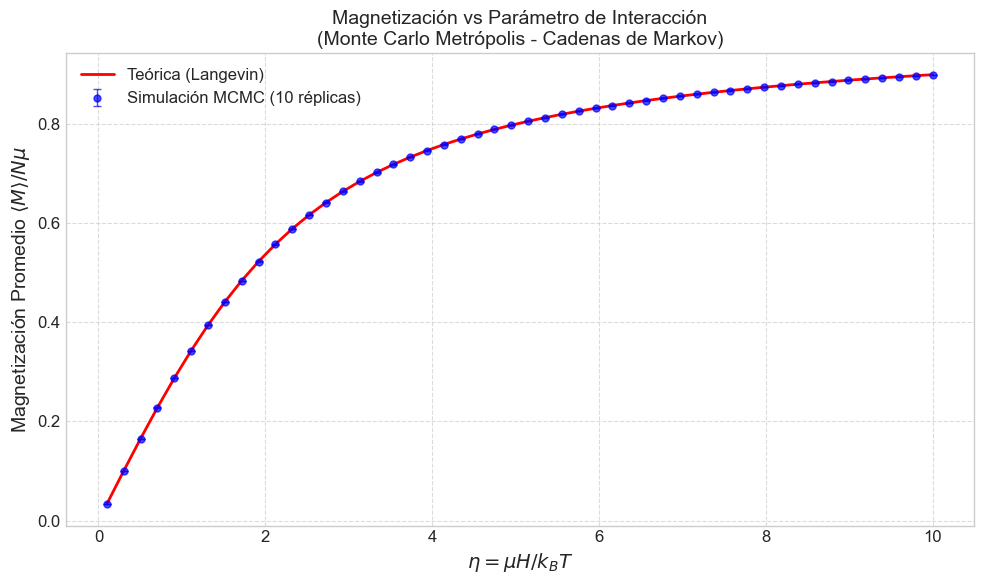

In [4]:
# Graficar Magnetización con barras de error
plt.figure(figsize=(10, 6))

# Curva teórica de Langevin
plt.plot(etas, mag_theo, 'r-', linewidth=2, label='Teórica (Langevin)')

# Datos de simulación MCMC con barras de error (desviación estándar de 10 réplicas)
plt.errorbar(etas, mag_mean, yerr=mag_std, fmt='bo', markersize=5, alpha=0.7, 
             capsize=3, capthick=1, elinewidth=1,
             label=f'Simulación MCMC ({N_REPLICAS} réplicas)')

plt.xlabel(r'$\eta = \mu H / k_B T$', fontsize=14)
plt.ylabel(r'Magnetización Promedio $\langle M \rangle / N\mu$', fontsize=14)
plt.title('Magnetización vs Parámetro de Interacción\n(Monte Carlo Metrópolis - Cadenas de Markov)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

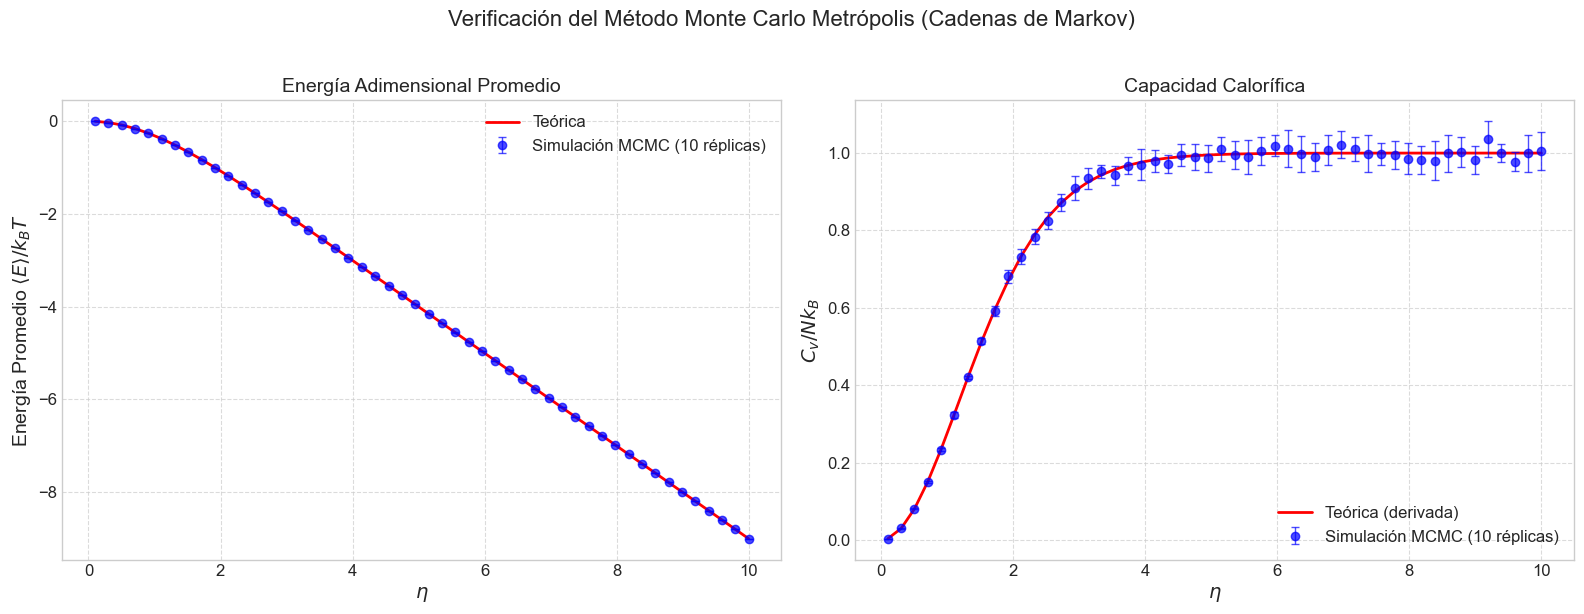

In [5]:
# Graficar Energía y Capacidad Calorífica con barras de error
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# === Energía ===
ax1.plot(etas, ener_theo, 'r-', linewidth=2, label='Teórica')
ax1.errorbar(etas, ener_mean, yerr=ener_std, fmt='bo', alpha=0.7,
             capsize=3, capthick=1, elinewidth=1,
             label=f'Simulación MCMC ({N_REPLICAS} réplicas)')
ax1.set_xlabel(r'$\eta$', fontsize=14)
ax1.set_ylabel(r'Energía Promedio $\langle E \rangle / k_B T$', fontsize=14)
ax1.set_title('Energía Adimensional Promedio', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# === Capacidad Calorífica ===
ax2.plot(etas, cv_theo_vals, 'r-', linewidth=2, label='Teórica (derivada)')
ax2.errorbar(etas, cv_mean, yerr=cv_std, fmt='bo', alpha=0.7,
             capsize=3, capthick=1, elinewidth=1,
             label=f'Simulación MCMC ({N_REPLICAS} réplicas)')
ax2.set_xlabel(r'$\eta$', fontsize=14)
ax2.set_ylabel(r'$C_v / N k_B$', fontsize=14)
ax2.set_title('Capacidad Calorífica', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Verificación del Método Monte Carlo Metrópolis (Cadenas de Markov)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5. Evaluación de Ergodicidad

Para verificar la ergodicidad del sistema, simulamos la evolución temporal de la magnetización partiendo de dos condiciones iniciales extremas para un mismo valor de $\eta$ (por ejemplo, $\eta = 2$):

1.  **Inicio Ordenado (Cold Start)**: Todos los espines alineados con el campo ($S_z = 1$).
2.  **Inicio Aleatorio (Hot Start)**: Orientaciones al azar en la esfera ($S_z$ aleatorio).

Si el sistema es ergódico, ambas simulaciones deben converger al mismo valor de equilibrio de la magnetización después de un tiempo de relajación.

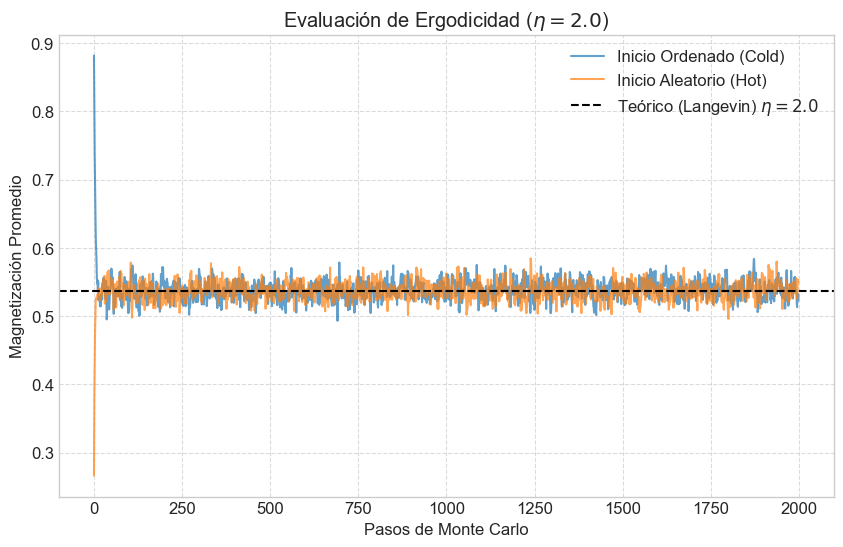

In [6]:
# Parámetros para prueba de ergodicidad
N_ergo = 1000
eta_test = 2.0
steps_ergo = 2000

# Simulación partida en frío (ordenada)
mag_cold = simulate_evolution(N_ergo, eta_test, steps_ergo, initial_state='ordered')

# Simulación partida en caliente (aleatoria)
mag_hot = simulate_evolution(N_ergo, eta_test, steps_ergo, initial_state='random')

# Graficar convergencia
plt.figure(figsize=(10, 6))
plt.plot(mag_cold, label='Inicio Ordenado (Cold)', alpha=0.7)
plt.plot(mag_hot, label='Inicio Aleatorio (Hot)', alpha=0.7)
plt.axhline(langevin(eta_test), color='k', linestyle='--', label=f'Teórico (Langevin) $\eta={eta_test}$')
plt.xlabel('Pasos de Monte Carlo')
plt.ylabel('Magnetización Promedio')
plt.title(f'Evaluación de Ergodicidad ($\\eta = {eta_test}$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

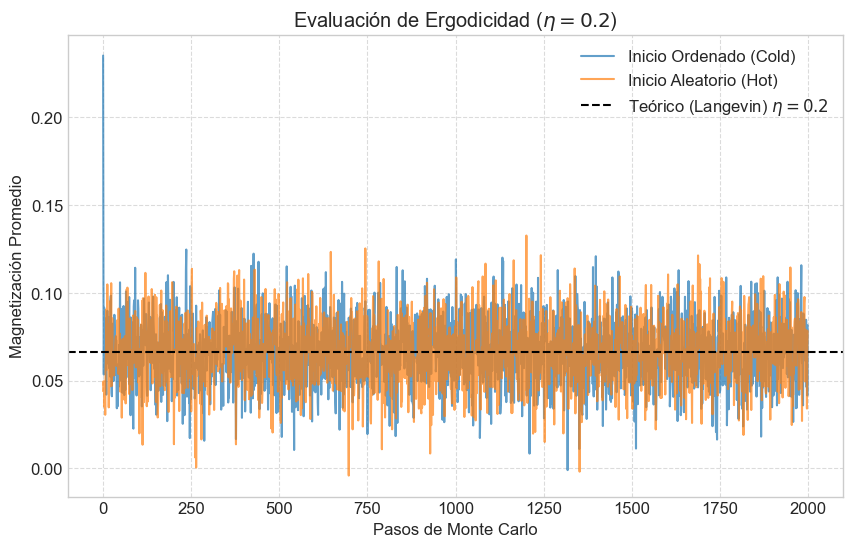

In [7]:
# Parámetros para prueba de ergodicidad
N_ergo = 1000
eta_test = 0.2
steps_ergo = 2000

# Simulación partida en frío (ordenada)
mag_cold = simulate_evolution(N_ergo, eta_test, steps_ergo, initial_state='ordered')

# Simulación partida en caliente (aleatoria)
mag_hot = simulate_evolution(N_ergo, eta_test, steps_ergo, initial_state='random')

# Graficar convergencia
plt.figure(figsize=(10, 6))
plt.plot(mag_cold, label='Inicio Ordenado (Cold)', alpha=0.7)
plt.plot(mag_hot, label='Inicio Aleatorio (Hot)', alpha=0.7)
plt.axhline(langevin(eta_test), color='k', linestyle='--', label=f'Teórico (Langevin) $\eta={eta_test}$')
plt.xlabel('Pasos de Monte Carlo')
plt.ylabel('Magnetización Promedio')
plt.title(f'Evaluación de Ergodicidad ($\\eta = {eta_test}$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Visualización de la Evolución en 2D

Para visualizar mejor cómo el sistema alcanza el equilibrio termodinámico, representamos los espines en una red cuadrada 2D.
Analizamos la evolución del sistema partiendo de dos configuraciones iniciales distintas:

1.  **Inicio Ordenado (Cold Start)**: Todos los espines comienzan alineados con el campo magnético ($S_z = 1$). Esto corresponde a una temperatura inicial de cero absoluto.
2.  **Inicio Desordenado (Hot Start)**: Los espines tienen orientaciones aleatorias. Esto corresponde a una temperatura inicial infinita.

El código a continuación genera una gráfica comparativa mostrando el estado inicial y el estado final de equilibrio para ambos casos. Usamos un código de colores donde **Rojo** indica alineación con el campo (Arriba) y **Azul** indica anti-alineación (Abajo).


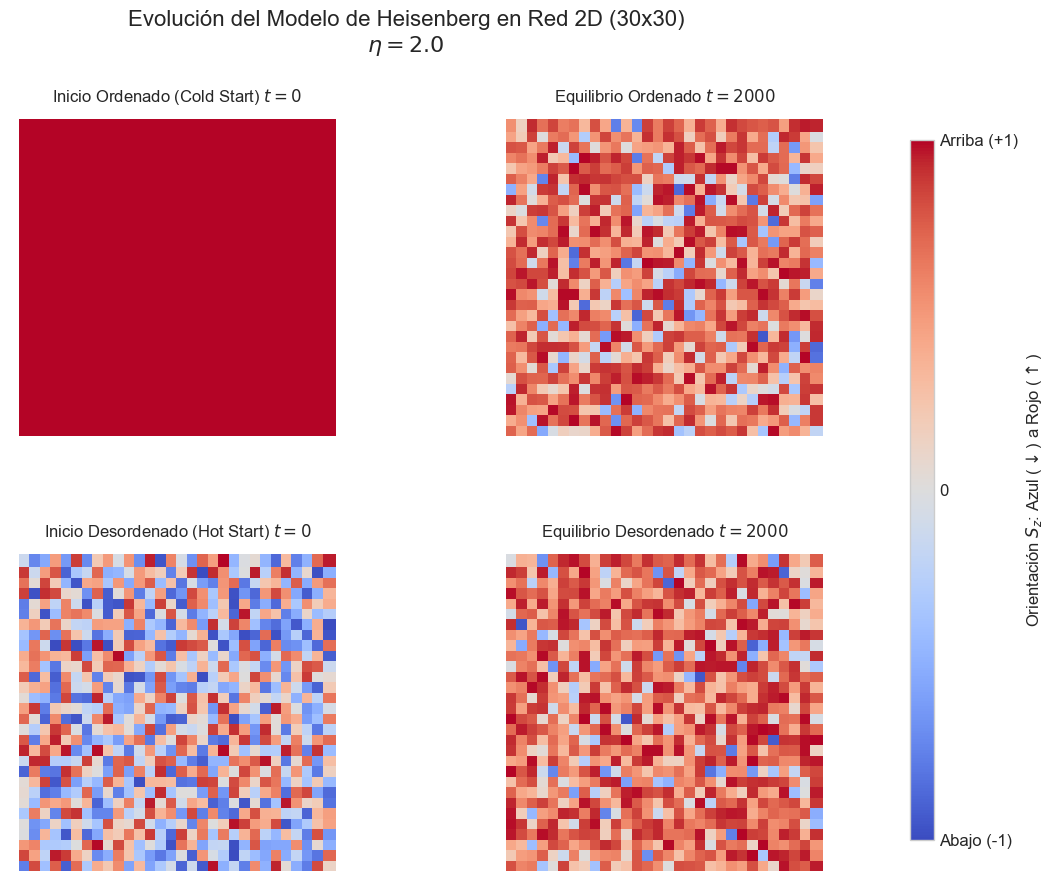

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir parámetros de la red 2D y simulación
L_2d = 30                # Lado de la red cuadrada (30x30 = 900 espines)
N_2d = L_2d * L_2d
eta_vis = 2.0            # Parametro de interacción (Campo/Temperatura)
steps_vis = 2000         # Pasos de Monte Carlo para alcanzar equilibrio

# 2. Funciones auxiliares
def init_spins_2d(mode='random'):
    spins = np.zeros((N_2d, 3))
    if mode == 'ordered':
        # Alineados en Z (0,0,1)
        spins[:, 2] = 1.0
        # Ajustar vectores unitarios x,y (son 0)
    else:
        # Aleatorios
        for i in range(N_2d):
            spins[i] = random_unit_vector()
    return spins

def evolve_system_2d(spins, eta, steps):
    # Copia para no modificar el original
    system = np.copy(spins)
    # Evolución (usamos la función metropolis_step ya definida previamente)
    # Nota: metropolis_step modifica 'system' in-place
    for _ in range(steps):
        metropolis_step(system, eta)
    return system

# 3. Preparar estados
spins_cold_0 = init_spins_2d('ordered')
spins_hot_0 = init_spins_2d('random')

spins_cold_final = evolve_system_2d(spins_cold_0, eta_vis, steps_vis)
spins_hot_final = evolve_system_2d(spins_hot_0, eta_vis, steps_vis)

# 4. Graficar
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Evolución del Modelo de Heisenberg en Red 2D ({L_2d}x{L_2d})\n$\\eta = {eta_vis}$', fontsize=16)

# Coordenadas para scatter plot
x, y = np.meshgrid(np.arange(L_2d), np.arange(L_2d))
x_flat = x.flatten()
y_flat = y.flatten()

def plot_lattice(ax, spins, title):
    # Extraer componente Z para el color
    sz = spins[:, 2]
    # Scatter plot: cuadrados compactos
    sc = ax.scatter(x_flat, y_flat, c=sz, cmap='coolwarm', 
                    vmin=-1, vmax=1, s=90, marker='s', edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.axis('off')
    return sc

# Fila 1: Cold Start
plot_lattice(axes[0,0], spins_cold_0, 'Inicio Ordenado (Cold Start) $t=0$')
plot_lattice(axes[0,1], spins_cold_final, f'Equilibrio Ordenado $t={steps_vis}$')

# Fila 2: Hot Start
plot_lattice(axes[1,0], spins_hot_0, 'Inicio Desordenado (Hot Start) $t=0$')
im = plot_lattice(axes[1,1], spins_hot_final, f'Equilibrio Desordenado $t={steps_vis}$')

# Barra de color común
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'Orientación $S_z$: Azul ($\downarrow $) a Rojo ($\uparrow $)', fontsize=12)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['Abajo (-1)', '0', 'Arriba (+1)'])

plt.subplots_adjust(wspace=0.1, hspace=0.3, right=0.9)
plt.show()

## 7. Conclusiones y Ley de Estados Correspondientes

1.  **Validación del Método**: Los resultados de la simulación de Monte Carlo coinciden notablemente con la curva analítica de Langevin. Esto demuestra que el algoritmo de Metrópolis muestrea correctamente la distribución de Boltzmann para el sistema de espines clásicos.
2.  **Verificación de la Ley de Estados Correspondientes**: La curva de magnetización obtenida demuestra que $M$ no depende de $H$ y $T$ por separado, sino únicamente de su cociente a través del parámetro $\eta = \mu H / k_B T$. Al graficar $M$ vs $\eta$, todos los estados termodinámicos colapsan en la curva universal de Langevin ($M = N \mu L(\eta)$), verificando así la **Ley de Estados Correspondientes** para el paramagnetismo clásico.
3.  **Ergodicidad**: Como se observa en la sección de evaluación, el sistema converge al mismo estado de equilibrio independientemente de la condición inicial (ordenada o aleatoria), confirmando el comportamiento ergódico del algoritmo de Metrópolis en este modelo.
4.  **Límite de Alta Temperatura ($\\eta \\to 0$)**: La magnetización tiende linealmente a cero, recuperando la **Ley de Curie** (susceptibilidad $\chi \propto 1/T$).
5.  **Saturación**: A valores altos de $\eta$ (campo fuerte o $T \to 0$), la magnetización satura a su valor máximo $N\mu$, indicando alineación total.